# ColdChain AI
### Intelligent Cold-Chain Temperature Excursion Detection & Risk Analytics

**Important:** This deadline-ready prototype uses a clearly labelled simulated sensor dataset. It is designed to demonstrate the analytics/AI workflow; it should not be presented as live operational data.


## 1. Problem Statement
Temperature-sensitive products can be exposed to unsuitable conditions during transportation. The objective is to analyze multi-sensor cold-chain data, detect temperature excursions and unusual sensor behaviour, and convert those findings into an explainable shipment risk view.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from pathlib import Path

df = pd.read_csv('../data/cold_chain_sensor_data.csv', parse_dates=['timestamp'])
df.head()

,shipment_id,timestamp,route,product_type,sensor_position,temperature_c,humidity_pct,simulated_excursion
0,CC001,2026-08-01 08:00:00,Route-A,Strawberries,Front-Top,4.224993,83.008506,0
1,CC001,2026-08-01 08:00:00,Route-A,Strawberries,Front-Bottom,4.639256,83.908271,0
2,CC001,2026-08-01 08:00:00,Route-A,Strawberries,Middle-Top,4.974471,84.464486,0
3,CC001,2026-08-01 08:00:00,Route-A,Strawberries,Middle-Bottom,5.139083,84.247288,0
4,CC001,2026-08-01 08:00:00,Route-A,Strawberries,Rear-Top,5.122554,83.248814,0


## 2. Dataset Overview
The prototype dataset contains shipment ID, timestamp, route, product type, sensor position, temperature, humidity and a simulated excursion flag. The excursion flag is used only for demonstration/validation; it is not supplied to the anomaly model.

In [10]:
print('Rows:', len(df))
print('Columns:', len(df.columns))
print('Shipments:', df['shipment_id'].nunique())
print('Sensor positions:', df['sensor_position'].nunique())
print('Date range:', df['timestamp'].min(), 'to', df['timestamp'].max())
df.describe(include='all')

Rows: 28800
Columns: 8
Shipments: 8
Sensor positions: 6
Date range: 2026-08-01 08:00:00 to 2026-09-09 11:50:00


,shipment_id,timestamp,route,product_type,sensor_position,temperature_c,humidity_pct,simulated_excursion
count,28800,28800,28800,28800,28800,28800.000000,28800.000000,28800.000000
unique,8,NaN,4,1,6,NaN,NaN,NaN
top,CC001,NaN,Route-A,Strawberries,Front-Top,NaN,NaN,NaN
freq,3600,NaN,7200,28800,4800,NaN,NaN,NaN
mean,NaN,2026-08-20 21:55:00,NaN,NaN,NaN,5.284982,86.175618,0.080903
min,NaN,2026-08-01 08:00:00,NaN,NaN,NaN,3.265468,80.031885,0.000000
25%,NaN,2026-08-11 02:57:30,NaN,NaN,NaN,4.678123,84.549809,0.000000
50%,NaN,2026-08-20 21:55:00,NaN,NaN,NaN,5.004910,86.091876,0.000000
75%,NaN,2026-08-30 16:52:30,NaN,NaN,NaN,5.361976,87.871788,0.000000
max,NaN,2026-09-09 11:50:00,NaN,NaN,NaN,13.515636,95.023778,1.000000


In [11]:
LOWER_LIMIT, UPPER_LIMIT = 2.0, 8.0
df['out_of_range'] = ((df['temperature_c'] < LOWER_LIMIT) | (df['temperature_c'] > UPPER_LIMIT)).astype(int)
print('Out-of-range observations:', int(df['out_of_range'].sum()))

Out-of-range observations: 1903


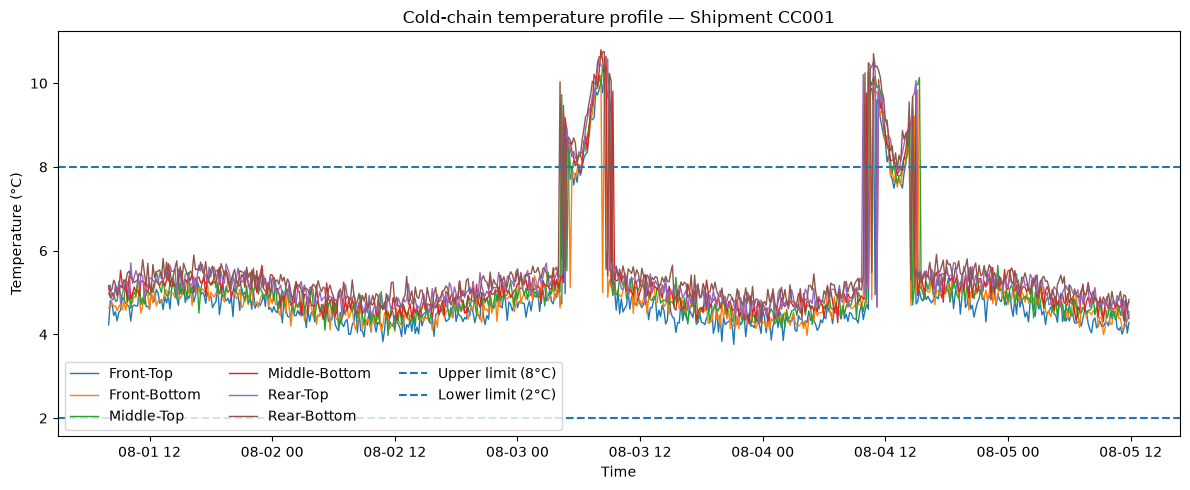

In [12]:
plt.figure(figsize=(12,5))
sample = df[df['shipment_id']=='CC001']
for sensor in sample['sensor_position'].unique():
    d = sample[sample['sensor_position']==sensor]
    plt.plot(d['timestamp'], d['temperature_c'], label=sensor, linewidth=1)
plt.axhline(8, linestyle='--', label='Upper limit (8°C)')
plt.axhline(2, linestyle='--', label='Lower limit (2°C)')
plt.title('Cold-chain temperature profile — Shipment CC001')
plt.xlabel('Time'); plt.ylabel('Temperature (°C)'); plt.legend(ncol=3)
plt.tight_layout(); plt.show()

## 3. Feature Engineering
We calculate short-term temperature change, rolling mean, rolling variability and absolute deviation. These features describe how sensor behaviour is changing rather than relying only on one raw reading.

In [13]:
df = df.sort_values(['shipment_id','sensor_position','timestamp'])
g = df.groupby(['shipment_id','sensor_position'], group_keys=False)
df['temp_change'] = g['temperature_c'].diff().fillna(0)
df['rolling_mean_60m'] = g['temperature_c'].transform(lambda x: x.rolling(6, min_periods=1).mean())
df['rolling_std_60m'] = g['temperature_c'].transform(lambda x: x.rolling(6, min_periods=1).std().fillna(0))
df['abs_deviation'] = (df['temperature_c'] - df['rolling_mean_60m']).abs()
df[['temperature_c','temp_change','rolling_mean_60m','rolling_std_60m','abs_deviation']].head(10)

,temperature_c,temp_change,rolling_mean_60m,rolling_std_60m,abs_deviation
1,4.639256,0.000000,4.639256,0.000000,0.000000
7,4.642794,0.003538,4.641025,0.002502,0.001769
13,4.757957,0.115164,4.680002,0.067534,0.077955
19,4.665863,-0.092094,4.676468,0.055593,0.010604
25,4.680410,0.014547,4.677256,0.048177,0.003154
31,4.566505,-0.113905,4.658797,0.062459,0.092293
37,4.660577,0.094072,4.662351,0.061727,0.001774
43,4.725713,0.065136,4.676171,0.065632,0.049542
49,4.589067,-0.136647,4.648023,0.059467,0.058956
55,4.777853,0.188787,4.666688,0.080161,0.111166


## 4. AI Anomaly Detection
Isolation Forest is used as an unsupervised anomaly-detection model. It flags observations whose feature patterns are unusual compared with the rest of the dataset.

In [14]:
features = ['temperature_c','humidity_pct','temp_change','rolling_std_60m','abs_deviation']
X = df[features].replace([np.inf,-np.inf],np.nan).fillna(0)
model = IsolationForest(n_estimators=150, contamination=0.06, random_state=42)
df['ai_anomaly'] = (model.fit_predict(X) == -1).astype(int)
df['anomaly_score'] = -model.score_samples(X)
print('AI anomaly rate:', round(df['ai_anomaly'].mean()*100,2), '%')

AI anomaly rate: 6.0 %


In [15]:
df['risk_score'] = (
    0.55*np.clip((df['temperature_c']-UPPER_LIMIT).abs()/6,0,1)
    + 0.30*np.clip(df['rolling_std_60m']/2,0,1)
    + 0.15*df['ai_anomaly']
)*100
df['risk_level'] = pd.cut(df['risk_score'], bins=[-1,25,55,101], labels=['Low','Medium','High'])
df[['shipment_id','sensor_position','temperature_c','ai_anomaly','risk_score','risk_level']].sort_values('risk_score', ascending=False).head(10)

,shipment_id,sensor_position,temperature_c,ai_anomaly,risk_score,risk_level
8735,CC003,Rear-Bottom,12.761609,1,88.648086,High
8729,CC003,Rear-Bottom,12.640571,1,87.538572,High
8723,CC003,Rear-Bottom,12.422016,1,85.535144,High
8711,CC003,Rear-Bottom,12.311230,1,84.519604,High
12996,CC004,Front-Top,3.813894,1,83.372638,High
12972,CC004,Front-Top,3.872145,1,82.838669,High
24120,CC007,Front-Top,3.872615,1,82.834365,High
8717,CC003,Rear-Bottom,12.096226,1,82.548736,High
12984,CC004,Front-Top,3.917350,1,82.424294,High
13206,CC004,Front-Top,3.563862,1,82.364872,High


## 5. Executive Insights
- Temperature excursions are identified using the defined operating band.
- AI anomaly detection adds a behavioural layer beyond simple threshold rules.
- Sensor position can be compared to identify locations that show larger deviations.
- Risk scoring converts multiple signals into an interpretable operational indicator.

**Operational interpretation:** A high-risk observation should trigger investigation of the refrigeration/handling process; it should not by itself be interpreted as proof that a product is spoiled.

In [16]:
sensor_summary = df.groupby('sensor_position').agg(
    avg_temp=('temperature_c','mean'),
    max_temp=('temperature_c','max'),
    excursion_rate=('out_of_range','mean'),
    anomaly_rate=('ai_anomaly','mean')
).sort_values('excursion_rate', ascending=False)
sensor_summary

,avg_temp,max_temp,excursion_rate,anomaly_rate
sensor_position,,,,
Rear-Bottom,5.627516,13.515636,0.081042,0.067917
Rear-Top,5.458969,11.189976,0.068125,0.060208
Middle-Bottom,5.341997,10.890415,0.067500,0.055208
Middle-Top,5.216768,10.888261,0.064792,0.060833
Front-Bottom,5.096363,10.905512,0.059375,0.059167
Front-Top,4.968278,10.654927,0.055625,0.056667
